In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# DynamicModel 224x224 Image and 5 Conv Blocks
# Using OverSampled high-alert and 0.002 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.DynamicModel import DynamicModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3)
])

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 2
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    sampler = sampler
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 16` 
* `initial_image_size = 128`
* `poolings = [1,1,1,1]`
* `normalizations = [1, 1, 1, 1]`,
* `dropouts = [0, 1, 0, 1]`

In [6]:
model = DynamicModel(
    conv_layers=5, 
    normalizations = [1, 1, 1, 1, 1],
    poolings = [0, 1, 1, 1, 1],
    dropouts = [0, 0, 1, 0, 1],
    initial_output_channel=12, 
    initial_image_size=224,
    dropout_p = 0.3,
    activations=["tanh"],
    activation_outputs=[8]
    ).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=60,
    lr=0.002,
    print_on=5,
    save_dir="../models/dynamic_img224_c5_lr_0.002_a_1/",
    save_checkpoints=1,
    checkpoint_name="dynamic_224x224_a1_train_0_",
    early_stop_patience = 10,
    min_delta = 0.001
)

Epoch 5/60 | Train Loss: 0.6567 | Valid Loss: 0.8323
Epoch 10/60 | Train Loss: 0.4650 | Valid Loss: 0.6727
Epoch 15/60 | Train Loss: 0.3886 | Valid Loss: 0.6812
Epoch 20/60 | Train Loss: 0.3446 | Valid Loss: 0.6081
Epoch 25/60 | Train Loss: 0.3014 | Valid Loss: 0.6112
Early stopping at epoch 30 | No improvement for 10 epochs


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [8]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [9]:
metrics

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,valid_loss,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,1.036881,0.482058,0.456361,0.481847,0.412560,0.966853,0.487505,0.481037,0.487163,0.332334
1,2,0.906041,0.571721,0.558350,0.571238,0.519805,1.018773,0.469716,0.457802,0.542619,0.396140
2,3,0.814425,0.637705,0.628618,0.637295,0.620158,1.053086,0.501482,0.505254,0.578025,0.451533
3,4,0.731255,0.692577,0.687692,0.692985,0.687935,0.818129,0.601017,0.525468,0.579127,0.517485
4,5,0.656723,0.730237,0.726077,0.729992,0.726619,0.832302,0.553579,0.502866,0.415644,0.388562
5,6,0.604087,0.754736,0.752115,0.754863,0.752511,0.738438,0.667514,0.559448,0.576021,0.562820
6,7,0.556596,0.775956,0.772848,0.775444,0.773375,0.859674,0.636595,0.587857,0.615074,0.551849
7,8,0.529359,0.787250,0.784978,0.787759,0.785750,0.703557,0.691233,0.585629,0.573218,0.572231
8,9,0.487854,0.803233,0.801046,0.803676,0.801825,0.673387,0.721728,0.609206,0.599879,0.602074
9,10,0.464973,0.811521,0.809582,0.811822,0.810290,0.672664,0.723422,0.617524,0.558575,0.567549


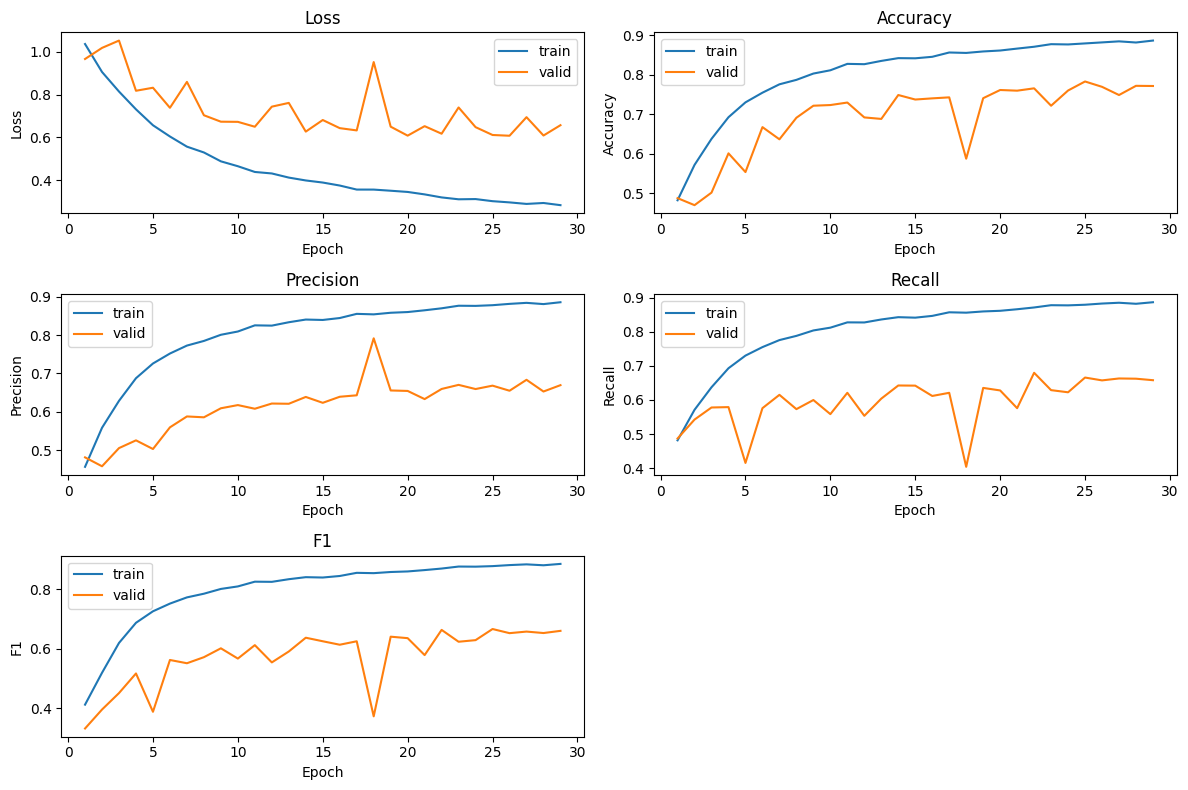

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"valid_{metric}",
        ax=ax,
        label="valid"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()